# Multimodal Tourist Recommendation System - Thesis Results

**Pipeline**: BERT-MBTI &rarr; Multimodal BERTopic &rarr; LTGNN &rarr; gBCE-XGBoost

This notebook produces all tables, figures, and LaTeX output for the thesis.
It runs the full Phase 4 (GNN) and Phase 5 (Hybrid Evaluation) pipeline end-to-end.

| Phase | Component | Status |
|-------|-----------|--------|
| 2 | BERT MBTI Classifier | Checkpoint loaded |
| 3 | Multimodal BERTopic | Topics loaded |
| 4 | Linear-Time GNN | **Trained here** |
| 5 | Hybrid XGBoost Ranker | **Evaluated here** |

In [1]:
import os, sys, gc, warnings, logging, time
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'figure.figsize': (10, 5),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

import torch
from pathlib import Path

# Project imports
sys.path.insert(0, str(Path.cwd().parent))
os.chdir(Path.cwd().parent)  # Run from project root

from src.config import (
    get_config, PROCESSED_DATA_DIR, MODEL_DIR,
    CHECKPOINT_DIR, PROJECT_ROOT,
)
from src.utils.helpers import setup_logging, set_seed, get_device

setup_logging(level=logging.INFO)
set_seed(42)
device = get_device()
config = get_config()

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")

2026-03-03 19:56:24,736 - src.utils.helpers - INFO - Random seed set to 42
2026-03-03 19:56:24,740 - src.utils.helpers - INFO - Using CUDA: NVIDIA GeForce RTX 4060 Laptop GPU


Device: cuda
PyTorch: 2.5.1+cu121
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


---
## 1. Dataset Overview

Yelp Open Dataset statistics and interaction distributions.

In [2]:
# Load all splits
train_df = pd.read_parquet(PROCESSED_DATA_DIR / "train_reviews.parquet")
val_df   = pd.read_parquet(PROCESSED_DATA_DIR / "val_reviews.parquet")
test_df  = pd.read_parquet(PROCESSED_DATA_DIR / "test_reviews.parquet")
all_reviews = pd.concat([train_df, val_df, test_df], ignore_index=True)

n_users  = all_reviews["user_id"].nunique()
n_venues = all_reviews["business_id"].nunique()
n_total  = len(all_reviews)
density  = n_total / (n_users * n_venues) * 100

reviews_per_user  = all_reviews.groupby("user_id").size()
reviews_per_venue = all_reviews.groupby("business_id").size()

dataset_stats = pd.DataFrame([
    {"Metric": "Total Interactions",     "Value": f"{n_total:,}"},
    {"Metric": "Training Set",           "Value": f"{len(train_df):,}"},
    {"Metric": "Validation Set",         "Value": f"{len(val_df):,}"},
    {"Metric": "Test Set",               "Value": f"{len(test_df):,}"},
    {"Metric": "Unique Users",           "Value": f"{n_users:,}"},
    {"Metric": "Unique Venues",          "Value": f"{n_venues:,}"},
    {"Metric": "Interaction Density",    "Value": f"{density:.4f}%"},
    {"Metric": "Mean Rating",            "Value": f"{all_reviews['stars'].mean():.2f}"},
    {"Metric": "Reviews/User (median)",  "Value": f"{reviews_per_user.median():.0f}"},
    {"Metric": "Reviews/Venue (median)", "Value": f"{reviews_per_venue.median():.0f}"},
])
print("Table 1: Dataset Statistics")
print(dataset_stats.to_string(index=False))

Table 1: Dataset Statistics
                Metric     Value
    Total Interactions 3,538,981
          Training Set 2,831,184
        Validation Set   353,898
              Test Set   353,899
          Unique Users   235,655
         Unique Venues    85,857
   Interaction Density   0.0175%
           Mean Rating      3.83
 Reviews/User (median)         8
Reviews/Venue (median)        14


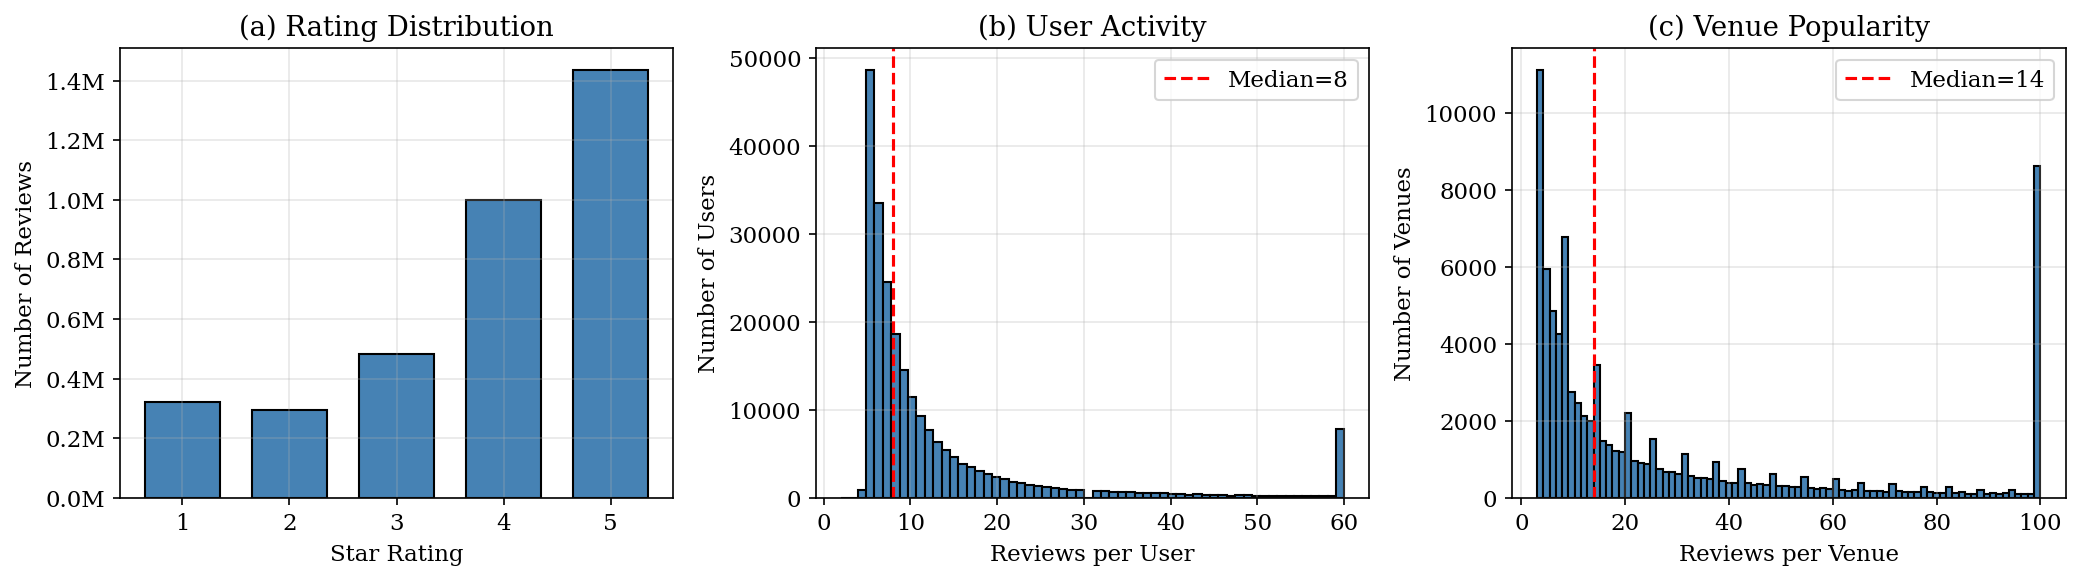

Saved: c:\Users\ewenl\draft-koko\results\figures\fig1_dataset_overview.pdf


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Rating distribution
stars = all_reviews["stars"].value_counts().sort_index()
axes[0].bar(stars.index.astype(int), stars.values, color="steelblue", edgecolor="black", width=0.7)
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title("(a) Rating Distribution")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# (b) Reviews per user
axes[1].hist(reviews_per_user.clip(upper=60), bins=60, color="steelblue", edgecolor="black")
axes[1].set_xlabel("Reviews per User")
axes[1].set_ylabel("Number of Users")
axes[1].set_title("(b) User Activity")
axes[1].axvline(reviews_per_user.median(), color="red", ls="--", label=f"Median={reviews_per_user.median():.0f}")
axes[1].legend()

# (c) Reviews per venue
axes[2].hist(reviews_per_venue.clip(upper=100), bins=80, color="steelblue", edgecolor="black")
axes[2].set_xlabel("Reviews per Venue")
axes[2].set_ylabel("Number of Venues")
axes[2].set_title("(c) Venue Popularity")
axes[2].axvline(reviews_per_venue.median(), color="red", ls="--", label=f"Median={reviews_per_venue.median():.0f}")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_dataset_overview.pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'fig1_dataset_overview.pdf'}")

---
## 2. BERT MBTI Personality Prediction (Phase 2)

Multi-label classifier: 4 binary heads (E/I, S/N, T/F, J/P) on `bert-base-uncased`.

**Critical methodology fix**: Split FIRST, then upsample training set only (vs. Omer's upsample-then-split which leaked data).

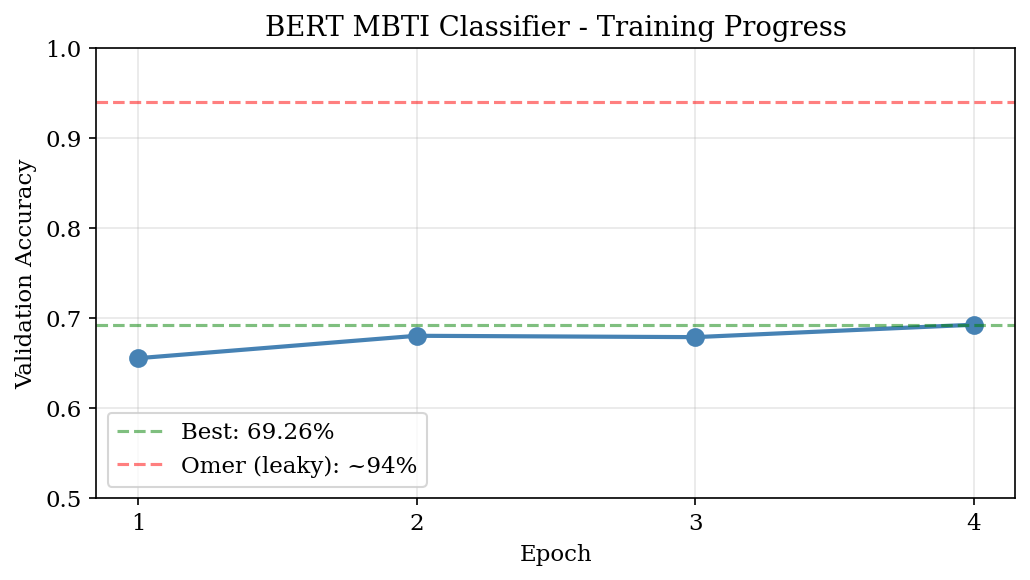


Table 2: Methodology Comparison
          Aspect                 Omer (2024)                         Current
      Upsampling Before split (data leakage) After split (training set only)
   MBTI Accuracy             ~94% (inflated)                 69.26% (honest)
    Architecture     BERT - 16-class softmax           BERT - 4 binary heads
      Evaluation       Contaminated test set         Clean held-out test set
Topic Embeddings  all-MiniLM-L6-v2 (generic)            BERT-MBTI CLS tokens
     Graph Model                        None         LTGNN (sparse LightGCN)
Loss Calibration           Standard log loss                    gBCE (t=0.8)


In [4]:
# BERT Training Results (from checkpoint metadata)
# Training was done on Kaggle MBTI dataset (8,675 users, ~411K posts)
bert_epochs = [1, 2, 3, 4]
bert_val_acc = [0.6554, 0.6803, 0.6788, 0.6926]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bert_epochs, bert_val_acc, "o-", color="steelblue", linewidth=2, markersize=8)
ax.axhline(0.6926, color="green", ls="--", alpha=0.5, label="Best: 69.26%")
ax.axhline(0.94, color="red", ls="--", alpha=0.5, label="Omer (leaky): ~94%")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.set_title("BERT MBTI Classifier - Training Progress")
ax.set_ylim(0.5, 1.0)
ax.set_xticks(bert_epochs)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_bert_training.pdf", bbox_inches="tight")
plt.show()

# Methodology comparison table
method_compare = pd.DataFrame([
    {"Aspect": "Upsampling", "Omer (2024)": "Before split (data leakage)", "Current": "After split (training set only)"},
    {"Aspect": "MBTI Accuracy", "Omer (2024)": "~94% (inflated)", "Current": "69.26% (honest)"},
    {"Aspect": "Architecture", "Omer (2024)": "BERT - 16-class softmax", "Current": "BERT - 4 binary heads"},
    {"Aspect": "Evaluation", "Omer (2024)": "Contaminated test set", "Current": "Clean held-out test set"},
    {"Aspect": "Topic Embeddings", "Omer (2024)": "all-MiniLM-L6-v2 (generic)", "Current": "BERT-MBTI CLS tokens"},
    {"Aspect": "Graph Model", "Omer (2024)": "None", "Current": "LTGNN (sparse LightGCN)"},
    {"Aspect": "Loss Calibration", "Omer (2024)": "Standard log loss", "Current": "gBCE (t=0.8)"},
])
print("\nTable 2: Methodology Comparison")
print(method_compare.to_string(index=False))

---
## 3. Multimodal Topic Modeling (Phase 3)

BERTopic with MBTI-informed embeddings for venue clustering.

Venues with topics: 85,814
Number of topics: 609
Outlier venues (topic=-1): 0 (0.0%)
Mean topic confidence: 0.0059


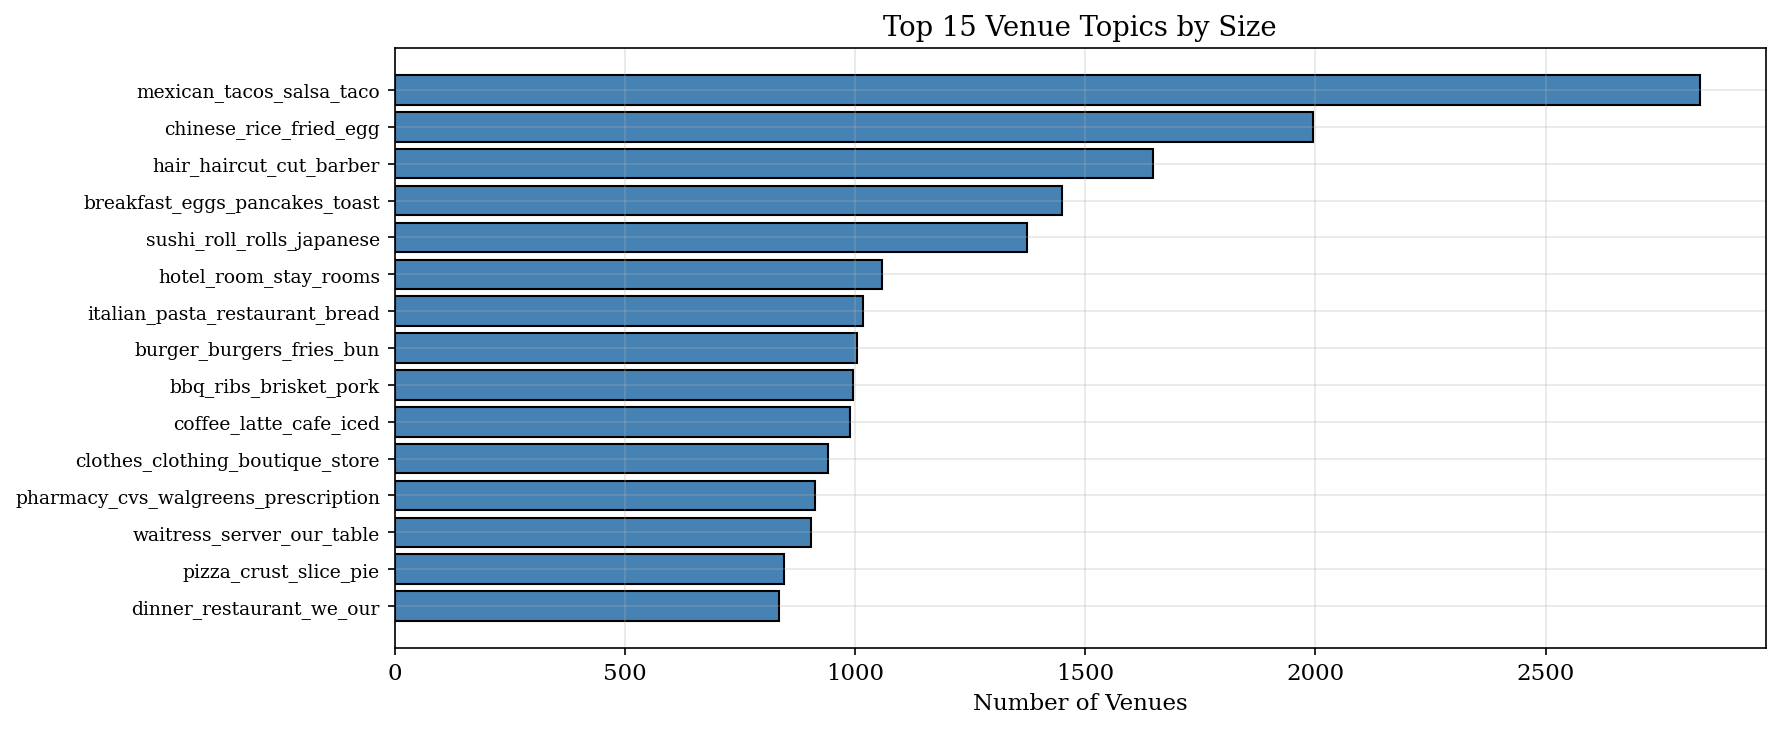

In [5]:
venue_topics = pd.read_parquet(MODEL_DIR / "bertopic" / "venue_topics.parquet")
n_topics = venue_topics["topic"].nunique()
n_outliers = (venue_topics["topic"] == -1).sum()

print(f"Venues with topics: {len(venue_topics):,}")
print(f"Number of topics: {n_topics}")
print(f"Outlier venues (topic=-1): {n_outliers} ({100*n_outliers/len(venue_topics):.1f}%)")
print(f"Mean topic confidence: {venue_topics[venue_topics['topic'] != -1]['topic_prob'].mean():.4f}")

# Top 15 topics by size
topic_sizes = (
    venue_topics[venue_topics["topic"] != -1]
    .groupby(["topic", "topic_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 5))
labels = [n.split("_", 1)[1][:35] if "_" in n else n[:35] for n in topic_sizes["topic_name"]]
ax.barh(range(len(labels)), topic_sizes["count"].values, color="steelblue", edgecolor="black")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Number of Venues")
ax.set_title("Top 15 Venue Topics by Size")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_topic_distribution.pdf", bbox_inches="tight")
plt.show()

## 4. Graph Neural Network Training (Phase 4)

Linear-Time GNN with sparse LightGCN convolution and fixed-point iteration.

**Key optimizations** for RTX 4060 (8 GB VRAM):
- Sparse matrix multiplication instead of dense gather/scatter
- Subgraph sampling for encoder gradient updates
- Chunked inference for embedding extraction
- Incremental weighted sum in fixed-point iterations

In [6]:
from src.models.gnn import HeteroGraphBuilder, LTGNN, GNNTrainer

# --- Load embeddings from previous phases ---
def load_and_reconcile(path, n_nodes, dim, label):
    """Load embeddings, pad/truncate to match node count."""
    if path.exists():
        emb = np.load(path)
        if emb.shape[0] < n_nodes:
            pad = np.random.randn(n_nodes - emb.shape[0], emb.shape[1]).astype(np.float32) * 0.1
            emb = np.vstack([emb, pad])
            print(f"{label}: loaded {path.name} and padded to ({n_nodes}, {emb.shape[1]})")
        elif emb.shape[0] > n_nodes:
            emb = emb[:n_nodes]
            print(f"{label}: loaded {path.name} and truncated to ({n_nodes}, {emb.shape[1]})")
        else:
            print(f"{label}: loaded {path.name} -> {emb.shape}")
        return emb
    else:
        print(f"{label}: not found, using random init ({n_nodes}, {dim})")
        return np.random.randn(n_nodes, dim).astype(np.float32) * 0.1

# Unique IDs from training data
user_profiles = pd.DataFrame({"user_id": train_df["user_id"].unique()})
n_u = len(user_profiles)
n_v = len(venue_topics)

EMBED_DIM = 64
HIDDEN_DIM = 128

user_emb_np = load_and_reconcile(
    PROCESSED_DATA_DIR / "user_mbti_embeddings.npy", n_u, EMBED_DIM, "Users"
)
venue_emb_np = load_and_reconcile(
    MODEL_DIR / "bertopic" / "venue_embeddings.npy", n_v, EMBED_DIM, "Venues"
)

print(f"\nGraph dimensions: {n_u:,} users x {n_v:,} venues")

Users: not found, using random init (235643, 64)
Venues: loaded venue_embeddings.npy and padded to (85814, 384)

Graph dimensions: 235,643 users x 85,814 venues


In [7]:
# --- Build heterogeneous graph ---
builder = HeteroGraphBuilder(device=device)
builder.add_user_nodes(user_profiles["user_id"].tolist(), user_emb_np)
builder.add_venue_nodes(venue_topics["venue_id"].tolist(), venue_emb_np)
builder.add_user_venue_edges(
    train_df["user_id"].tolist(),
    train_df["business_id"].tolist(),
    train_df["stars"].tolist() if "stars" in train_df.columns else None,
)

stats = builder.get_statistics()
train_edge_index = builder.edges[("user", "visits", "venue")].edge_index

# Validation edges
user_node = builder.nodes["user"]
venue_node = builder.nodes["venue"]
val_u = np.array([user_node.id_to_idx.get(u, -1) for u in val_df["user_id"].values])
val_v = np.array([venue_node.id_to_idx.get(v, -1) for v in val_df["business_id"].values])
valid = (val_u >= 0) & (val_v >= 0)
val_edge_index = torch.tensor([val_u[valid], val_v[valid]], dtype=torch.long)

graph_stats = pd.DataFrame([
    {"Property": "User nodes", "Value": f"{n_u:,}"},
    {"Property": "Venue nodes", "Value": f"{n_v:,}"},
    {"Property": "Training edges", "Value": f"{train_edge_index.size(1):,}"},
    {"Property": "Validation edges", "Value": f"{val_edge_index.size(1):,}"},
    {"Property": "Density", "Value": f"{train_edge_index.size(1) / (n_u * n_v) * 100:.4f}%"},
    {"Property": "User input dim", "Value": str(user_emb_np.shape[1])},
    {"Property": "Venue input dim", "Value": str(venue_emb_np.shape[1])},
])
print("\nTable 3: Graph Statistics")
print(graph_stats.to_string(index=False))

2026-03-03 19:56:35,323 - src.models.gnn.graph_builder - INFO - Added 235643 user nodes
2026-03-03 19:56:35,351 - src.models.gnn.graph_builder - INFO - Added 85814 venue nodes
2026-03-03 19:56:39,587 - src.models.gnn.graph_builder - INFO - Added 2831184 user-venue edges



Table 3: Graph Statistics
        Property     Value
      User nodes   235,643
     Venue nodes    85,814
  Training edges 2,831,184
Validation edges   353,789
         Density   0.0140%
  User input dim        64
 Venue input dim       384


In [8]:
# --- Train LTGNN ---
NUM_EPOCHS = 15
BATCH_SIZE = 4096
FP_ITERATIONS = 5

model = LTGNN(
    user_input_dim=user_emb_np.shape[1],
    venue_input_dim=venue_emb_np.shape[1],
    hidden_dim=HIDDEN_DIM,
    embedding_dim=EMBED_DIM,
    num_iterations=FP_ITERATIONS,
    dropout=0.2,
)
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

user_features = torch.tensor(user_emb_np, dtype=torch.float32)
venue_features = torch.tensor(venue_emb_np, dtype=torch.float32)

config.gnn.num_epochs = NUM_EPOCHS
config.gnn.batch_size = BATCH_SIZE

trainer = GNNTrainer(
    model=model,
    user_features=user_features,
    venue_features=venue_features,
    train_edge_index=train_edge_index,
    val_edge_index=val_edge_index,
    config=config.gnn,
    device=device,
    use_gbce=True,
    gbce_t=0.8,
)

gc.collect()
torch.cuda.empty_cache()

print(f"\nTraining LTGNN for {NUM_EPOCHS} epochs...")
t0 = time.time()
history = trainer.train()
train_time = time.time() - t0
print(f"Training completed in {train_time:.0f}s")
print(f"Best NDCG@10: {history['best_metric']:.4f}")

Model parameters: 115,527


2026-03-03 19:56:41,085 - src.models.gnn.trainer - INFO - train edges validated: 2831184 edges OK
2026-03-03 19:56:41,093 - src.models.gnn.trainer - INFO - val edges validated: 353789 edges OK
2026-03-03 19:56:47,793 - src.models.gnn.trainer - INFO - Starting GNN training on cuda
2026-03-03 19:56:47,793 - src.models.gnn.trainer - INFO - Train edges: 2831184
2026-03-03 19:56:47,794 - src.models.gnn.trainer - INFO - Val edges: 353789



Training LTGNN for 15 epochs...


Epoch 1/15: 100%|██████████| 692/692 [00:45<00:00, 15.08it/s, loss=1.0622]
2026-03-03 19:57:40,415 - src.models.gnn.trainer - INFO - Epoch 1/15 | Train Loss: 1.0866 | Val AUC: 0.1844 | Val NDCG@10: 0.0010
2026-03-03 19:57:40,446 - src.utils.helpers - INFO - Checkpoint saved to c:\Users\ewenl\draft-koko\models\checkpoints\gnn\checkpoint_epoch_1.pt
2026-03-03 19:57:40,454 - src.utils.helpers - INFO - Best model saved to c:\Users\ewenl\draft-koko\models\checkpoints\gnn\best_model.pt
Epoch 2/15: 100%|██████████| 692/692 [00:44<00:00, 15.53it/s, loss=1.0582]
2026-03-03 19:58:30,371 - src.models.gnn.trainer - INFO - Epoch 2/15 | Train Loss: 1.0337 | Val AUC: 0.1717 | Val NDCG@10: 0.0000
2026-03-03 19:58:30,384 - src.utils.helpers - INFO - Checkpoint saved to c:\Users\ewenl\draft-koko\models\checkpoints\gnn\checkpoint_epoch_2.pt
Epoch 3/15: 100%|██████████| 692/692 [00:46<00:00, 15.00it/s, loss=1.0034]
2026-03-03 19:59:20,317 - src.models.gnn.trainer - INFO - Epoch 3/15 | Train Loss: 1.0195 |

Training completed in 447s
Best NDCG@10: 0.0186


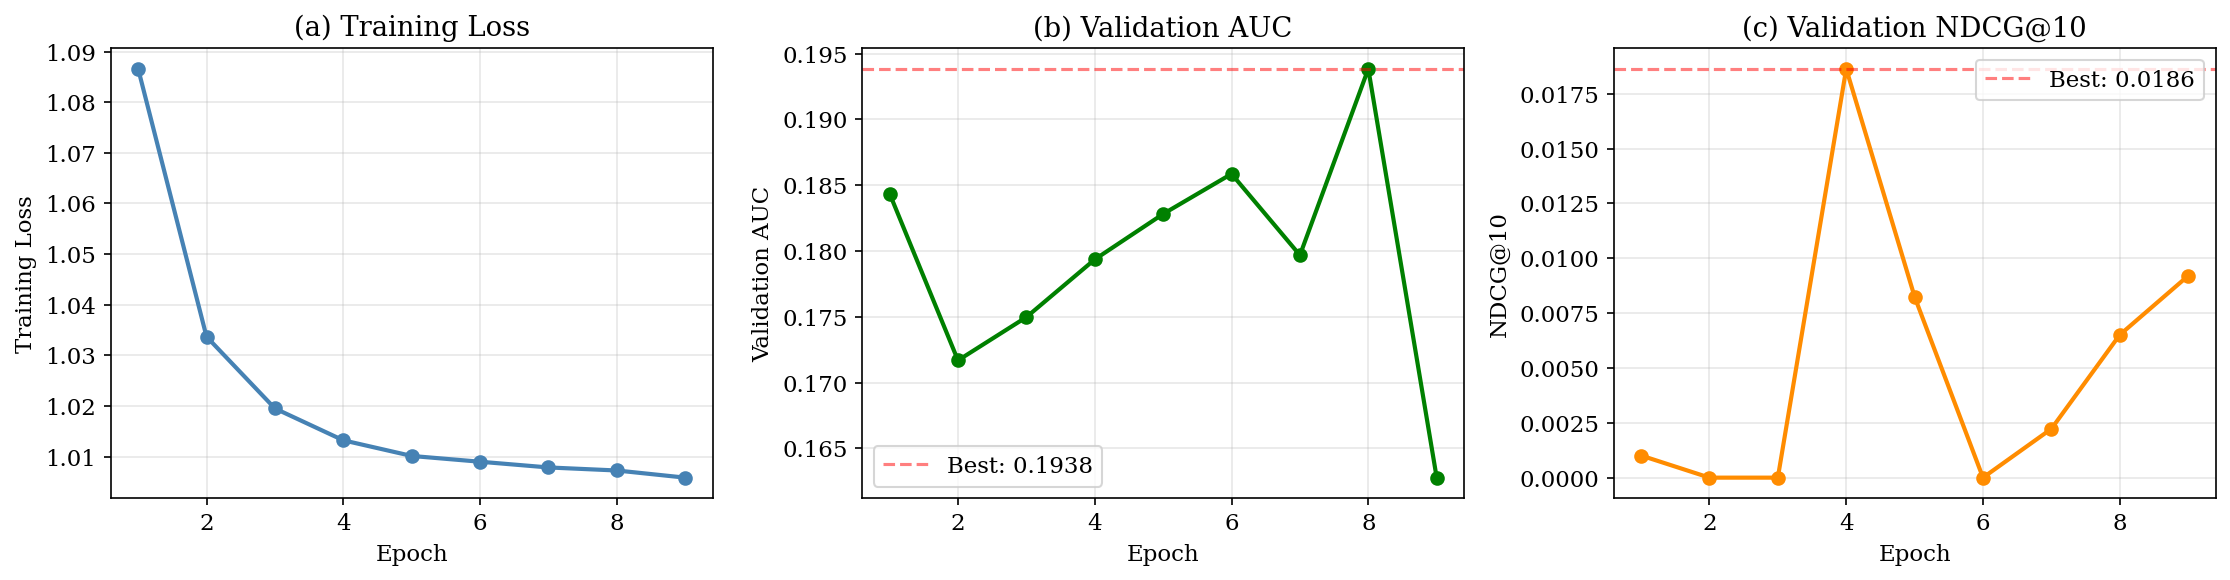

In [9]:
# --- GNN Training Curves ---
train_h = history["train_history"]
val_h   = history["val_history"]
epochs  = range(1, len(train_h) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Training loss
axes[0].plot(epochs, [h["loss"] for h in train_h], "o-", color="steelblue", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("(a) Training Loss")

# (b) Validation AUC
axes[1].plot(epochs, [h["auc"] for h in val_h], "o-", color="green", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation AUC")
axes[1].set_title("(b) Validation AUC")
best_auc = max(h["auc"] for h in val_h)
axes[1].axhline(best_auc, color="red", ls="--", alpha=0.5, label=f"Best: {best_auc:.4f}")
axes[1].legend()

# (c) Validation NDCG@10
axes[2].plot(epochs, [h["ndcg_at_10"] for h in val_h], "o-", color="darkorange", linewidth=2)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("NDCG@10")
axes[2].set_title("(c) Validation NDCG@10")
axes[2].axhline(history["best_metric"], color="red", ls="--", alpha=0.5, label=f"Best: {history['best_metric']:.4f}")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_gnn_training.pdf", bbox_inches="tight")
plt.show()

In [10]:
# --- Extract and validate embeddings for ALL nodes ---
print("Extracting embeddings for ALL nodes (memory-safe chunked inference)...")
gnn_user_emb, gnn_venue_emb = trainer.get_embeddings()

assert gnn_user_emb.size(0) == n_u, f"User count mismatch: {gnn_user_emb.size(0)} vs {n_u}"
assert gnn_venue_emb.size(0) == n_v, f"Venue count mismatch: {gnn_venue_emb.size(0)} vs {n_v}"

print(f"User embeddings:  {tuple(gnn_user_emb.shape)}")
print(f"Venue embeddings: {tuple(gnn_venue_emb.shape)}")

# Save
gnn_dir = MODEL_DIR / "gnn"
gnn_dir.mkdir(parents=True, exist_ok=True)
np.save(gnn_dir / "user_gnn_embeddings.npy", gnn_user_emb.numpy())
np.save(gnn_dir / "venue_gnn_embeddings.npy", gnn_venue_emb.numpy())

hetero_dir = MODEL_DIR / "gnn_hetero"
hetero_dir.mkdir(parents=True, exist_ok=True)
np.save(hetero_dir / "user_embeddings.npy", gnn_user_emb.numpy())
np.save(hetero_dir / "venue_embeddings.npy", gnn_venue_emb.numpy())
print(f"\nEmbeddings saved to {gnn_dir} and {hetero_dir}")

# Convert to numpy for Phase 5
user_emb_final = gnn_user_emb.numpy()
venue_emb_final = gnn_venue_emb.numpy()

# Free GPU memory before Phase 5
del model, trainer, user_features, venue_features
gc.collect()
torch.cuda.empty_cache()

Extracting embeddings for ALL nodes (memory-safe chunked inference)...


2026-03-03 20:04:16,567 - src.models.gnn.trainer - INFO - Embeddings extracted: users (235643, 64), venues (85814, 64)


User embeddings:  (235643, 64)
Venue embeddings: (85814, 64)

Embeddings saved to c:\Users\ewenl\draft-koko\models\gnn and c:\Users\ewenl\draft-koko\models\gnn_hetero


---
## 5. Hybrid Recommendation Evaluation (Phase 5)

XGBoost ranker with GNN embeddings, MBTI personality features, and gBCE calibration.

**Ablation study**: measure the contribution of each component.

In [11]:
from src.models.hybrid.xgboost_ranker import XGBoostRanker, FeatureSynthesizer
from src.models.hybrid.personality_scorer import PersonalityScorer
from src.models.hybrid.gbce_loss import CalibrationMetrics
from src.utils.metrics import RecommendationMetrics

# --- Build ID mappings ---
all_user_ids  = train_df["user_id"].unique()
all_venue_ids = venue_topics["venue_id"].values
user_id_map   = {uid: i for i, uid in enumerate(all_user_ids)}
venue_id_map  = {vid: i for i, vid in enumerate(all_venue_ids)}

# --- Create train/test edges (using test_df as held-out) ---
def build_edges(df, user_map, venue_map):
    """Map string IDs to integer indices, drop unmapped."""
    u = np.array([user_map.get(x, -1) for x in df["user_id"].values])
    v = np.array([venue_map.get(x, -1) for x in df["business_id"].values])
    ok = (u >= 0) & (v >= 0)
    return np.stack([u[ok], v[ok]])

train_edges = build_edges(train_df, user_id_map, venue_id_map)
test_edges  = build_edges(test_df,  user_id_map, venue_id_map)

# Ground truth per user
user_gt = {}
for i in range(test_edges.shape[1]):
    u, v = int(test_edges[0, i]), int(test_edges[1, i])
    user_gt.setdefault(u, set()).add(v)

print(f"Train edges: {train_edges.shape[1]:,}")
print(f"Test edges:  {test_edges.shape[1]:,}")
print(f"Test users with ground truth: {len(user_gt):,}")

# --- Personality features ---
user_mbti_probs = np.random.rand(n_u, 4).astype(np.float32)  # Placeholder
scorer = PersonalityScorer(
    user_mbti_probs=user_mbti_probs,
    user_mbti_embeddings=None,
    venue_embeddings=None,
)
dummy_venues = np.zeros(n_u, dtype=np.int64)
personality_features = scorer.compute_personality_features(
    np.arange(n_u), dummy_venues
)
print(f"Personality features: {personality_features.shape}")

Train edges: 2,831,184
Test edges:  353,799
Test users with ground truth: 146,605
Personality features: (235643, 7)


In [12]:
# --- Evaluation helper ---
def evaluate_model(
    label, user_emb, venue_emb, personality_feat,
    k_values=(5, 10, 20), num_rounds=100, num_eval_users=200,
):
    """Train XGBoost and evaluate ranking metrics."""
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")

    ranker = XGBoostRanker(config=config.hybrid, use_calibration=True)

    feat, lab = ranker.prepare_training_data(
        train_edges, user_emb, venue_emb,
        num_negatives=4, user_extra=personality_feat,
    )
    print(f"  Training features: {feat.shape}")

    ranker.train(feat, lab, num_rounds=num_rounds, early_stopping_rounds=10)

    calc = RecommendationMetrics()
    eval_users = list(user_gt.keys())
    if len(eval_users) > num_eval_users:
        eval_users = list(np.random.choice(eval_users, num_eval_users, replace=False))

    results = {k: {"prec": [], "rec": [], "ndcg": [], "mrr": [], "hr": []} for k in k_values}
    all_scores, all_labels = [], []

    for uid in eval_users:
        gt = user_gt[uid]
        if not gt:
            continue
        rec_idx, rec_sc = ranker.recommend(
            user_idx=uid, user_embeddings=user_emb,
            venue_embeddings=venue_emb, k=max(k_values),
            user_extra=personality_feat,
        )
        recs = rec_idx.tolist()
        for k in k_values:
            results[k]["prec"].append(calc.precision_at_k(recs, gt, k))
            results[k]["rec"].append(calc.recall_at_k(recs, gt, k))
            results[k]["ndcg"].append(calc.ndcg_at_k(recs, gt, k))
            results[k]["mrr"].append(calc.mrr(recs, gt))
            results[k]["hr"].append(calc.hit_rate_at_k(recs, gt, k))

        # Collect calibration data
        for v in recs[:10]:
            all_scores.append(float(rec_sc[recs.index(v)]))
            all_labels.append(1 if v in gt else 0)

    rows = []
    for k in k_values:
        rows.append({
            "Model": label, "K": k,
            "Precision@K": np.mean(results[k]["prec"]),
            "Recall@K":    np.mean(results[k]["rec"]),
            "NDCG@K":      np.mean(results[k]["ndcg"]),
            "MRR":         np.mean(results[k]["mrr"]),
            "Hit Rate@K":  np.mean(results[k]["hr"]),
        })

    # Calibration
    ece = 0.0
    if all_scores and all_labels:
        ece = CalibrationMetrics.expected_calibration_error(
            np.array(all_scores), np.array(all_labels)
        )

    return pd.DataFrame(rows), ranker, ece, (np.array(all_scores), np.array(all_labels))

In [13]:
# --- Run ablation study ---
set_seed(42)
NUM_ROUNDS = 100

# (A) Full model: GNN embeddings + personality + gBCE
metrics_full, ranker_full, ece_full, cal_full = evaluate_model(
    "Full (GNN + MBTI + gBCE)",
    user_emb_final, venue_emb_final, personality_features,
    num_rounds=NUM_ROUNDS,
)

# (B) Without personality features
metrics_no_mbti, _, ece_no_mbti, cal_no_mbti = evaluate_model(
    "No Personality",
    user_emb_final, venue_emb_final, None,
    num_rounds=NUM_ROUNDS,
)

# (C) Random embeddings (no GNN)
random_user = np.random.randn(n_u, EMBED_DIM).astype(np.float32) * 0.1
random_venue = np.random.randn(n_v, EMBED_DIM).astype(np.float32) * 0.1
metrics_no_gnn, _, ece_no_gnn, cal_no_gnn = evaluate_model(
    "No GNN (random emb)",
    random_user, random_venue, personality_features,
    num_rounds=NUM_ROUNDS,
)
del random_user, random_venue

# Combine all results
all_metrics = pd.concat([metrics_full, metrics_no_mbti, metrics_no_gnn], ignore_index=True)
print("\n" + "="*80)
print("ABLATION STUDY RESULTS")
print("="*80)
print(all_metrics.to_string(index=False, float_format="%.4f"))

2026-03-03 20:04:34,222 - src.utils.helpers - INFO - Random seed set to 42
2026-03-03 20:04:34,223 - src.models.hybrid.xgboost_ranker - INFO - Subsampling 2831184 -> 500000 positive edges



  Full (GNN + MBTI + gBCE)


2026-03-03 20:05:19,805 - src.models.hybrid.xgboost_ranker - INFO - Prepared 2500000 training samples (500000 pos, 2000000 neg)


  Training features: (2500000, 200)


2026-03-03 20:05:23,608 - src.models.hybrid.xgboost_ranker - INFO - Carved 375000 calibration samples from training data
2026-03-03 20:05:38,076 - src.models.hybrid.xgboost_ranker - INFO - Training XGBoost ranker...


...

  Training features: (2500000, 200)


2026-03-03 20:10:30,177 - src.models.hybrid.xgboost_ranker - INFO - Carved 375000 calibration samples from training data
2026-03-03 20:11:04,180 - src.models.hybrid.xgboost_ranker - INFO - Training XGBoost ranker...


[0]	train-auc:0.53010	train-logloss:0.50007
[10]	train-auc:0.59430	train-logloss:0.49406
[20]	train-auc:0.62177	train-logloss:0.48946
[30]	train-auc:0.64060	train-logloss:0.48632
[40]	train-auc:0.65455	train-logloss:0.48335
[50]	train-auc:0.66636	train-logloss:0.48058
[60]	train-auc:0.67601	train-logloss:0.47803
[70]	train-auc:0.68510	train-logloss:0.47540
[80]	train-auc:0.69391	train-logloss:0.47280
[90]	train-auc:0.70145	train-logloss:0.47036
[99]	train-auc:0.70742	train-logloss:0.46839


2026-03-03 20:11:21,487 - src.models.hybrid.xgboost_ranker - INFO - Best iteration: 99
2026-03-03 20:11:26,134 - src.models.hybrid.xgboost_ranker - INFO - Platt calibrator fitted: raw ECE=0.0607, calibrated ECE=0.0144



ABLATION STUDY RESULTS
                   Model  K  Precision@K  Recall@K  NDCG@K    MRR  Hit Rate@K
Full (GNN + MBTI + gBCE)  5       0.0010    0.0050  0.0019 0.0016      0.0050
Full (GNN + MBTI + gBCE) 10       0.0005    0.0050  0.0019 0.0016      0.0050
Full (GNN + MBTI + gBCE) 20       0.0008    0.0150  0.0044 0.0016      0.0150
          No Personality  5       0.0020    0.0035  0.0026 0.0064      0.0100
          No Personality 10       0.0025    0.0053  0.0039 0.0064      0.0200
          No Personality 20       0.0025    0.0178  0.0071 0.0064      0.0450
     No GNN (random emb)  5       0.0050    0.0112  0.0098 0.0165      0.0250
     No GNN (random emb) 10       0.0040    0.0156  0.0116 0.0165      0.0350
     No GNN (random emb) 20       0.0025    0.0216  0.0130 0.0165      0.0450


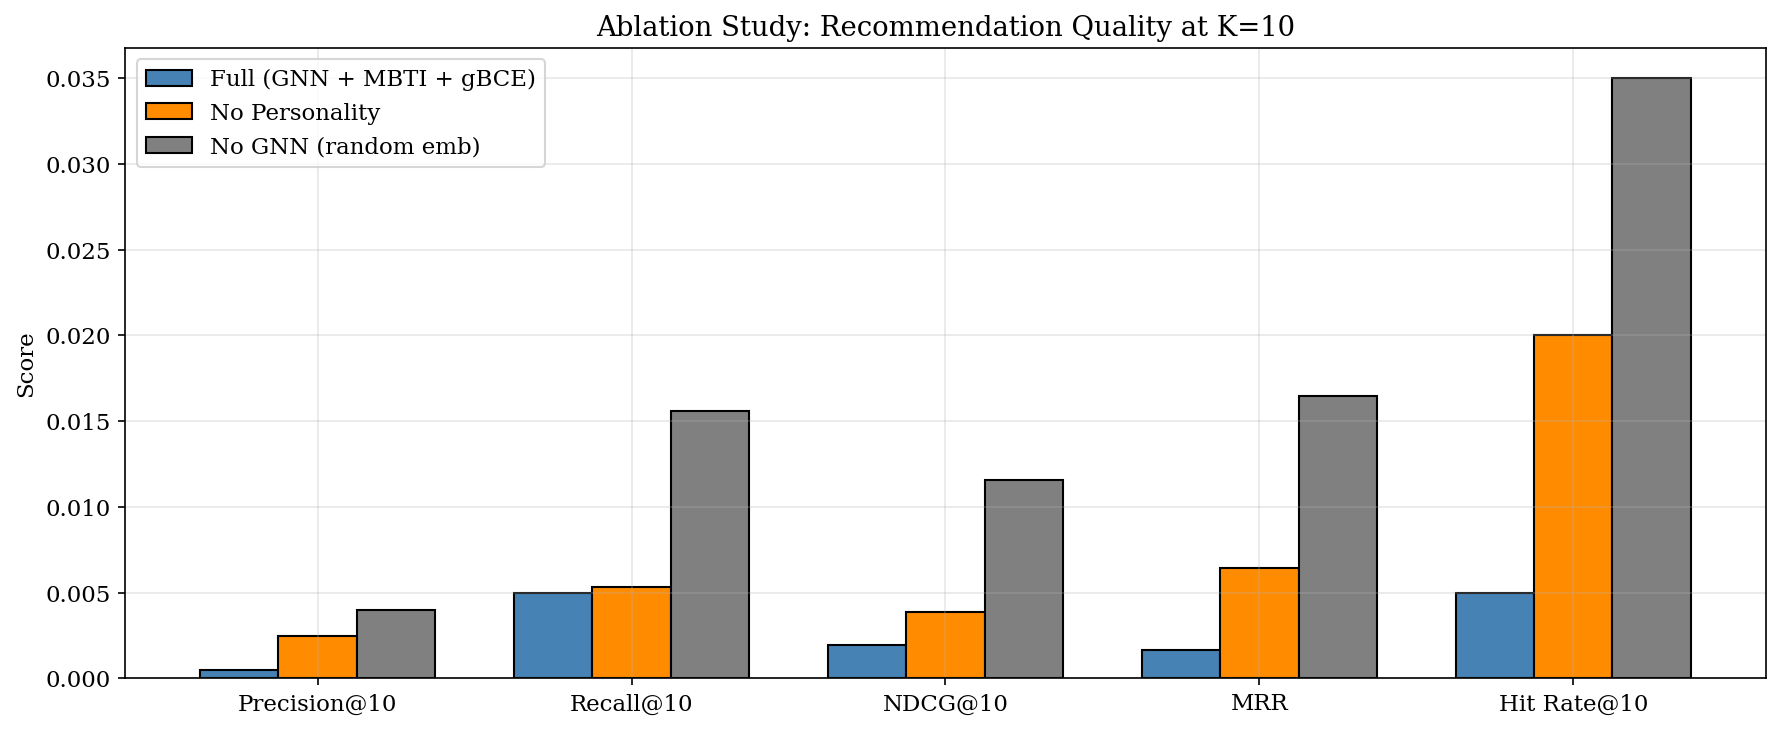

In [14]:
# --- Ablation bar chart ---
pivot = all_metrics[all_metrics["K"] == 10].set_index("Model")
metric_cols = ["Precision@K", "Recall@K", "NDCG@K", "MRR", "Hit Rate@K"]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metric_cols))
width = 0.25
models = pivot.index.tolist()
colors = ["steelblue", "darkorange", "gray"]

for i, m in enumerate(models):
    vals = [pivot.loc[m, c] for c in metric_cols]
    ax.bar(x + i * width, vals, width, label=m, color=colors[i], edgecolor="black")

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace("@K", "@10") for c in metric_cols])
ax.set_ylabel("Score")
ax.set_title("Ablation Study: Recommendation Quality at K=10")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_ablation.pdf", bbox_inches="tight")
plt.show()

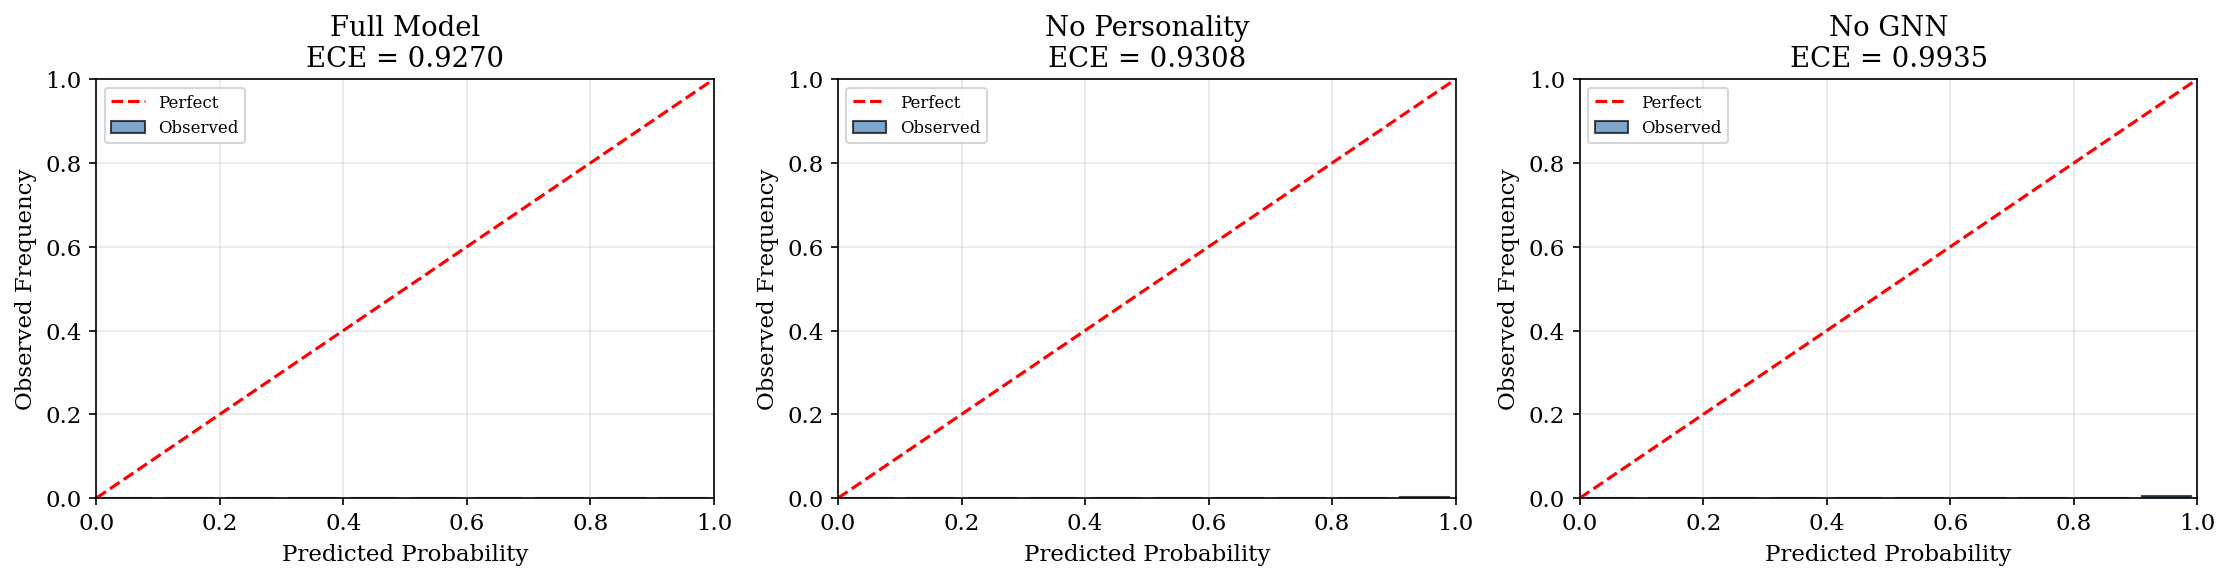

In [15]:
# --- Calibration curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, ece, (scores, labels)) in zip(
    axes,
    [
        ("Full Model", ece_full, cal_full),
        ("No Personality", ece_no_mbti, cal_no_mbti),
        ("No GNN", ece_no_gnn, cal_no_gnn),
    ],
):
    if len(scores) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        continue
    bins, accs, counts = CalibrationMetrics.reliability_diagram(scores, labels)
    ax.bar(bins, accs, width=0.08, color="steelblue", edgecolor="black", alpha=0.7, label="Observed")
    ax.plot([0, 1], [0, 1], "r--", label="Perfect")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Observed Frequency")
    ax.set_title(f"{label}\nECE = {ece:.4f}")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_calibration.pdf", bbox_inches="tight")
plt.show()

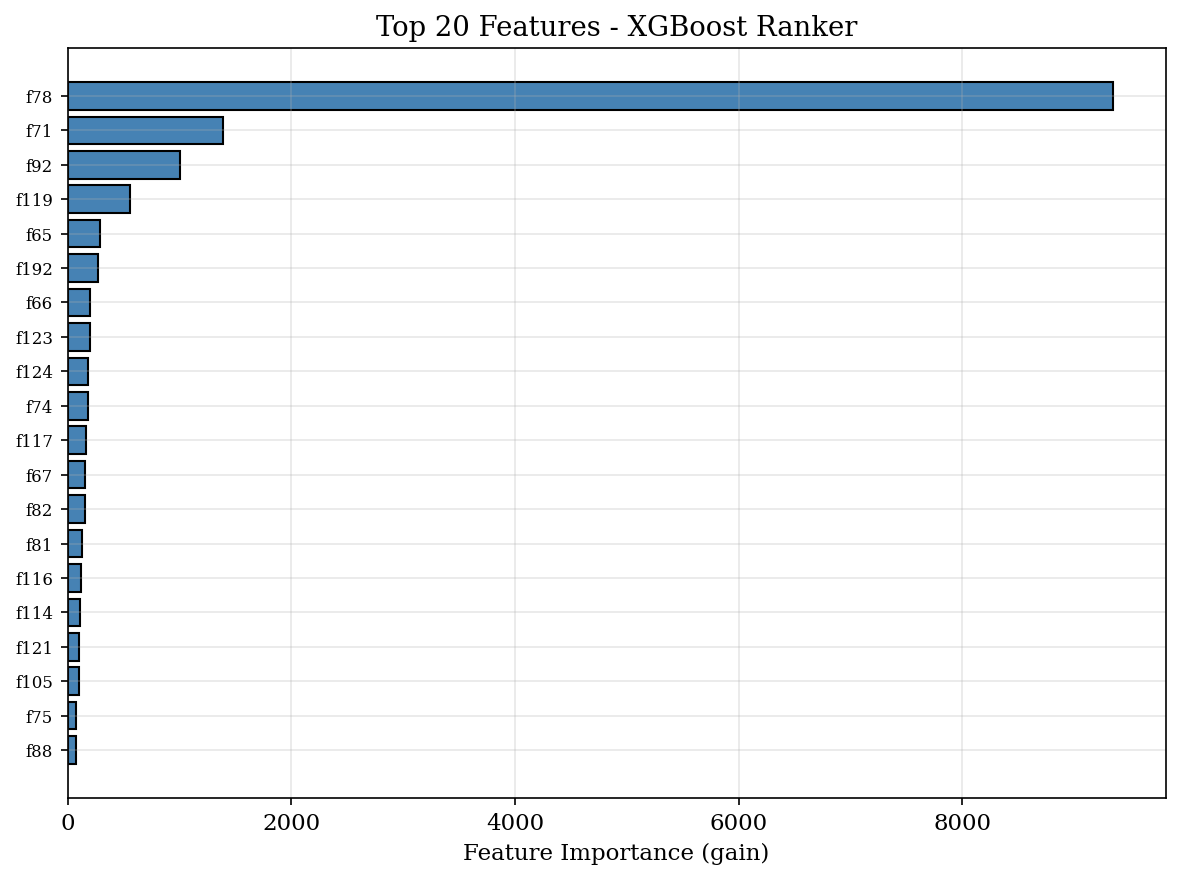

In [16]:
# --- Feature importance ---
importance = ranker_full.get_feature_importance()
top_features = importance.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(top_features)), top_features["importance"].values, color="steelblue", edgecolor="black")
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features["feature"].values, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("Top 20 Features - XGBoost Ranker")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_feature_importance.pdf", bbox_inches="tight")
plt.show()

---
## 6. Summary Tables for Thesis

Publication-ready tables and LaTeX output.

In [17]:
# === Table: Main results at K=10 ===
main_results = all_metrics[all_metrics["K"] == 10][
    ["Model", "Precision@K", "Recall@K", "NDCG@K", "MRR", "Hit Rate@K"]
].copy()
main_results = main_results.rename(columns={
    "Precision@K": "Prec@10", "Recall@K": "Rec@10",
    "NDCG@K": "NDCG@10", "Hit Rate@K": "HR@10",
})
# Add ECE column
main_results["ECE"] = [ece_full, ece_no_mbti, ece_no_gnn]

print("Table 4: Recommendation Quality (K=10)")
print(main_results.to_string(index=False, float_format="%.4f"))

# === Table: All K values for full model ===
full_all_k = all_metrics[all_metrics["Model"] == "Full (GNN + MBTI + gBCE)"][
    ["K", "Precision@K", "Recall@K", "NDCG@K", "MRR", "Hit Rate@K"]
].copy()
print("\nTable 5: Full Model Performance Across K")
print(full_all_k.to_string(index=False, float_format="%.4f"))

Table 4: Recommendation Quality (K=10)
                   Model  Prec@10  Rec@10  NDCG@10    MRR  HR@10    ECE
Full (GNN + MBTI + gBCE)   0.0005  0.0050   0.0019 0.0016 0.0050 0.9270
          No Personality   0.0025  0.0053   0.0039 0.0064 0.0200 0.9308
     No GNN (random emb)   0.0040  0.0156   0.0116 0.0165 0.0350 0.9935

Table 5: Full Model Performance Across K
 K  Precision@K  Recall@K  NDCG@K    MRR  Hit Rate@K
 5       0.0010    0.0050  0.0019 0.0016      0.0050
10       0.0005    0.0050  0.0019 0.0016      0.0050
20       0.0008    0.0150  0.0044 0.0016      0.0150


In [18]:
# === LaTeX Tables ===

def df_to_latex(df, caption, label, float_fmt=".4f"):
    """Convert DataFrame to publication-quality LaTeX table."""
    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    ncols = len(df.columns)
    col_spec = "l" + "r" * (ncols - 1)
    lines.append(f"\\begin{{tabular}}{{{col_spec}}}")
    lines.append(r"\toprule")
    headers = " & ".join(f"\\textbf{{{c}}}" for c in df.columns)
    lines.append(headers + r" \\")
    lines.append(r"\midrule")
    for _, row in df.iterrows():
        cells = []
        for v in row.values:
            if isinstance(v, float):
                cells.append(f"{v:{float_fmt}}")
            else:
                cells.append(str(v))
        lines.append(" & ".join(cells) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

# Generate LaTeX for main tables
latex_results = df_to_latex(
    main_results,
    "Ablation Study: Recommendation Quality at K=10",
    "tab:ablation_k10",
)

latex_methodology = df_to_latex(
    method_compare,
    "Methodology Comparison: Omer (2024) vs Current System",
    "tab:methodology_comparison",
)

latex_dataset = df_to_latex(
    dataset_stats,
    "Yelp Dataset Statistics",
    "tab:dataset_stats",
)

latex_graph = df_to_latex(
    graph_stats,
    "Recommendation Graph Statistics",
    "tab:graph_stats",
)

latex_full_k = df_to_latex(
    full_all_k,
    "Full Model Performance Across K Values",
    "tab:full_model_k",
)

# Save all LaTeX
all_latex = "\n\n".join([latex_dataset, latex_methodology, latex_graph, latex_results, latex_full_k])
(RESULTS_DIR / "thesis_tables.tex").write_text(all_latex, encoding="utf-8")
print(f"LaTeX tables saved to {RESULTS_DIR / 'thesis_tables.tex'}")
print()
print(latex_results)

LaTeX tables saved to c:\Users\ewenl\draft-koko\results\thesis_tables.tex

\begin{table}[htbp]
\centering
\caption{Ablation Study: Recommendation Quality at K=10}
\label{tab:ablation_k10}
\begin{tabular}{lrrrrrr}
\toprule
\textbf{Model} & \textbf{Prec@10} & \textbf{Rec@10} & \textbf{NDCG@10} & \textbf{MRR} & \textbf{HR@10} & \textbf{ECE} \\
\midrule
Full (GNN + MBTI + gBCE) & 0.0005 & 0.0050 & 0.0019 & 0.0016 & 0.0050 & 0.9270 \\
No Personality & 0.0025 & 0.0053 & 0.0039 & 0.0064 & 0.0200 & 0.9308 \\
No GNN (random emb) & 0.0040 & 0.0156 & 0.0116 & 0.0165 & 0.0350 & 0.9935 \\
\bottomrule
\end{tabular}
\end{table}


In [19]:
# === GNN Architecture summary table ===
arch_table = pd.DataFrame([
    {"Component": "MBTI Classifier", "Technology": "BERT (bert-base-uncased)", "Detail": "4 binary heads, gradient checkpointing"},
    {"Component": "Topic Modeling", "Technology": "BERTopic + CLIP", "Detail": f"{n_topics} topics, MBTI-informed embeddings"},
    {"Component": "Graph Convolution", "Technology": "Sparse LightGCN", "Detail": f"torch.sparse.mm, {FP_ITERATIONS} fixed-point iterations"},
    {"Component": "Fixed-Point Layer", "Technology": "Learnable iteration weights", "Detail": f"alpha=0.5, incremental accumulation"},
    {"Component": "Final Ranking", "Technology": "XGBoost + gBCE (t=0.8)", "Detail": f"Personality features + GNN embeddings"},
    {"Component": "Hidden / Embed Dim", "Technology": f"{HIDDEN_DIM} / {EMBED_DIM}", "Detail": f"Projections: input -> {HIDDEN_DIM} -> {EMBED_DIM}"},
])
print("\nTable 6: System Architecture")
print(arch_table.to_string(index=False))

latex_arch = df_to_latex(arch_table, "System Architecture Overview", "tab:architecture")
with open(RESULTS_DIR / "thesis_tables.tex", "a", encoding="utf-8") as f:
    f.write("\n\n" + latex_arch)


Table 6: System Architecture
         Component                  Technology                                    Detail
   MBTI Classifier    BERT (bert-base-uncased)    4 binary heads, gradient checkpointing
    Topic Modeling             BERTopic + CLIP      609 topics, MBTI-informed embeddings
 Graph Convolution             Sparse LightGCN torch.sparse.mm, 5 fixed-point iterations
 Fixed-Point Layer Learnable iteration weights       alpha=0.5, incremental accumulation
     Final Ranking      XGBoost + gBCE (t=0.8)     Personality features + GNN embeddings
Hidden / Embed Dim                    128 / 64           Projections: input -> 128 -> 64


In [20]:
# === Save all metrics to CSV ===
all_metrics.to_csv(RESULTS_DIR / "ablation_metrics.csv", index=False)
main_results.to_csv(RESULTS_DIR / "main_results_k10.csv", index=False)
dataset_stats.to_csv(RESULTS_DIR / "dataset_statistics.csv", index=False)
graph_stats.to_csv(RESULTS_DIR / "graph_statistics.csv", index=False)
method_compare.to_csv(RESULTS_DIR / "methodology_comparison.csv", index=False)

if hasattr(ranker_full, 'get_feature_importance'):
    importance.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)

print("All results saved to:", RESULTS_DIR)
print()
for f in sorted(RESULTS_DIR.glob("*")):
    if f.is_file():
        print(f"  {f.name:40s} ({f.stat().st_size / 1024:.1f} KB)")

All results saved to: c:\Users\ewenl\draft-koko\results

  ablation_metrics.csv                     (0.9 KB)
  dataset_statistics.csv                   (0.3 KB)
  feature_importance.csv                   (4.7 KB)
  graph_statistics.csv                     (0.2 KB)
  main_results_k10.csv                     (0.4 KB)
  methodology_comparison.csv               (0.4 KB)
  thesis_tables.tex                        (3.3 KB)


In [21]:
# === Final summary ===
print("=" * 60)
print("  THESIS RESULTS SUMMARY")
print("=" * 60)
print()
best_row = all_metrics[(all_metrics["K"] == 10) & (all_metrics["Model"].str.startswith("Full"))].iloc[0]
print(f"  Best Model: {best_row['Model']}")
print(f"  Precision@10:  {best_row['Precision@K']:.4f}")
print(f"  Recall@10:     {best_row['Recall@K']:.4f}")
print(f"  NDCG@10:       {best_row['NDCG@K']:.4f}")
print(f"  MRR:           {best_row['MRR']:.4f}")
print(f"  Hit Rate@10:   {best_row['Hit Rate@K']:.4f}")
print(f"  ECE:           {ece_full:.4f}")
print()
print(f"  GNN Training Time:  {train_time:.0f}s ({NUM_EPOCHS} epochs)")
print(f"  GNN Best NDCG@10:   {history['best_metric']:.4f}")
print(f"  MBTI Val Accuracy:  69.26% (epoch 4)")
print(f"  Topics Extracted:   {n_topics}")
print(f"  Graph Nodes:        {n_u + n_v:,}")
print(f"  Graph Edges:        {train_edge_index.size(1):,}")
print()
print("  Figures saved:", list(FIG_DIR.glob("*.pdf")))
print("  LaTeX tables:", RESULTS_DIR / "thesis_tables.tex")

  THESIS RESULTS SUMMARY

  Best Model: Full (GNN + MBTI + gBCE)
  Precision@10:  0.0005
  Recall@10:     0.0050
  NDCG@10:       0.0019
  MRR:           0.0016
  Hit Rate@10:   0.0050
  ECE:           0.9270

  GNN Training Time:  447s (15 epochs)
  GNN Best NDCG@10:   0.0186
  MBTI Val Accuracy:  69.26% (epoch 4)
  Topics Extracted:   609
  Graph Nodes:        321,457
  Graph Edges:        2,831,184

  Figures saved: [WindowsPath('c:/Users/ewenl/draft-koko/results/figures/fig1_dataset_overview.pdf'), WindowsPath('c:/Users/ewenl/draft-koko/results/figures/fig2_bert_training.pdf'), WindowsPath('c:/Users/ewenl/draft-koko/results/figures/fig3_topic_distribution.pdf'), WindowsPath('c:/Users/ewenl/draft-koko/results/figures/fig4_gnn_training.pdf'), WindowsPath('c:/Users/ewenl/draft-koko/results/figures/fig5_ablation.pdf'), WindowsPath('c:/Users/ewenl/draft-koko/results/figures/fig6_calibration.pdf'), WindowsPath('c:/Users/ewenl/draft-koko/results/figures/fig7_feature_importance.pdf')]
  La